# 실습 9: 혼동행렬과 분류 결과 리포트
- 상황: 정확도 하나로는 어느 모델이 나은지 답할 수 없다
- 목표: 틀린 것을 두 종류로 나눠 보고, 오늘 결과를 리포트 한 장으로 마감한다

## Step 0. 앞 실습까지 재현하기

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df = pd.read_csv("../../day02/lab06_clean-dataset/results/secom_clean.csv")

sensor_cols = [c for c in df.columns if c.startswith("sensor_")]
for c in sensor_cols:
    df[c] = df[c].fillna(df[c].median())

df["불량여부"] = (df["result"] == "불량").astype(int)

X = df[sensor_cols]
y = df["불량여부"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 로지스틱 회귀는 단위(스케일)를 맞춰야 하므로 표준화 (앞 실습과 동일)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 기본 설정 그대로, 불균형 보정 없음
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

예측 = model.predict(X_test_scaled)

print("학습용:", X_train.shape, " 시험용:", X_test.shape)
print("정확도:", round(accuracy_score(y_test, 예측) * 100, 2), "%")


학습용: (1253, 50)  시험용: (314, 50)
정확도: 93.95 %


## Step 1. 오늘 쓸 말 정리하기

### 용어 풀이 - 결과를 네 칸으로 나눠 볼 때 쓰는 말

| 말 | 뜻 |
|---|---|
| 혼동행렬 | 맞힌 것과 틀린 것을 네 칸으로 나눠 놓은 표 |
| 놓친 불량 | 불량인데 양품이라 한 것. 걸러지지 않고 고객에게 간다 |
| 헛경보 | 양품인데 불량이라 한 것. 멀쩡한 것을 세워 다시 본다 |
| 재현율 (recall) | 실제 불량 중 몇 %를 잡았나 |
| 정밀도 (precision) | 불량이라 한 것 중 진짜가 몇 %였나 |
| F1 | 재현율과 정밀도를 함께 보는 값. 한쪽만 좋으면 오르지 않는다 |

## Step 2. 네 칸으로 쪼개기

In [2]:
# confusion_matrix - 실제 답과 예측을 맞대어 네 칸으로 세어준다
from sklearn.metrics import confusion_matrix

행렬 = confusion_matrix(y_test, 예측)
print(행렬)

# ravel() - 네 칸을 한 줄로 펴서 하나씩 이름을 붙여 받는다
# 순서가 정해져 있다: 왼쪽위, 오른쪽위, 왼쪽아래, 오른쪽아래
맞힌양품, 헛경보, 놓친불량, 잡은불량 = 행렬.ravel()

print("양품인데 양품이라 함 :", 맞힌양품)
print("양품인데 불량이라 함 :", 헛경보,   " <- 헛경보")
print("불량인데 양품이라 함 :", 놓친불량, " <- 놓친 불량")
print("불량인데 불량이라 함 :", 잡은불량)

[[293   0]
 [ 19   2]]
양품인데 양품이라 함 : 293
양품인데 불량이라 함 : 0  <- 헛경보
불량인데 양품이라 함 : 19  <- 놓친 불량
불량인데 불량이라 함 : 2


## Step 3. 네 칸이 현장에서 무슨 상황인가

| 칸 | 내 숫자 | 현장에서는 |
|---|---|---|
| 양품인데 양품 | [293] | 아무 일 없음 |
| 양품인데 불량 (헛경보) | [0] | 멀쩡한 걸 세우고 다시 본다. 사람 손이 든다 |
| 불량인데 양품 (놓친 불량) | [19] | 걸러지지 않고 고객에게 간다 |
| 불량인데 불량 | [2] | 원하던 것. 미리 잡았다 |

## Step 4. 두 지표를 손으로 계산하기

In [3]:
# 재현율 - 실제 불량 중 몇 %를 잡았나
# 분모는 "실제 불량 전체" = 잡은 것 + 놓친 것
재현율 = 잡은불량 / (잡은불량 + 놓친불량)

# 정밀도 - 불량이라 한 것 중 진짜가 몇 %였나
# 분모는 "불량이라고 한 것 전체" = 진짜 + 헛경보
정밀도 = 잡은불량 / (잡은불량 + 헛경보)

print("재현율:", round(재현율, 3), " <- 실제 불량", 잡은불량 + 놓친불량, "건 중", 잡은불량, "건")
print("정밀도:", round(정밀도, 3), " <- 불량이라 한", 잡은불량 + 헛경보, "건 중", 잡은불량, "건")

재현율: 0.095  <- 실제 불량 21 건 중 2 건
정밀도: 1.0  <- 불량이라 한 2 건 중 2 건


### 문법 노트 - 네 칸에서 지표 뽑기

| 쓴 것 | 하는 일 | 왜 여기 쓰나 |
|---|---|---|
| confusion_matrix(실제, 예측) | 맞고 틀림을 네 칸으로 세어준다 | 정확도 하나로는 안 보이는 걸 본다 |
| .ravel() | 네 칸을 한 줄로 펴준다 | 칸마다 이름을 붙여 받으려고 |
| classification_report | 지표를 한 번에 계산해 표로 보여준다 | 손으로 구한 값과 맞춰보려고 |

**분자는 둘 다 같고 분모가 다르다.**<br>
재현율 = 잡은불량 / (잡은불량 + 놓친불량)   분모가 "실제 불량 전체"<br>
정밀도 = 잡은불량 / (잡은불량 + 헛경보)     분모가 "불량이라 한 것 전체"<br>
헷갈리면 분모부터 정하면 된다.

## Step 5. 라이브러리 출력과 대조하기

In [4]:
from sklearn.metrics import classification_report

# target_names - 0과 1 대신 사람이 읽을 이름을 붙인다
# digits=3 - 소수점 셋째 자리까지
print(classification_report(y_test, 예측,
                            target_names=["양품", "불량"], digits=3))

              precision    recall  f1-score   support

          양품      0.939     1.000     0.969       293
          불량      1.000     0.095     0.174        21

    accuracy                          0.939       314
   macro avg      0.970     0.548     0.571       314
weighted avg      0.943     0.939     0.915       314



## Step 6. 기준 모델의 재현율은 얼마인가

In [5]:
import numpy as np
import warnings
from sklearn.metrics import recall_score, precision_score, f1_score

# 전부 양품이라 답하는 기준 모델을 다시 만든다
기준예측 = np.zeros(len(y_test), dtype=int)

# 기준 모델은 불량이라 예측한 것이 0건이라, 정밀도(분모: 불량이라 한 것 전체)가 0/0이 된다
# -> 왜 이런 경고가 뜨는지 직접 확인
with warnings.catch_warnings(record=True) as 경고목록:
    warnings.simplefilter("always")
    _ = precision_score(y_test, 기준예측)
    if 경고목록:
        print("실제로 뜨는 경고:", 경고목록[-1].category.__name__, "-", str(경고목록[-1].message))

def 지표_행(이름, 예측값):
    정확도 = accuracy_score(y_test, 예측값) * 100
    재현율 = recall_score(y_test, 예측값, zero_division=0) * 100
    정밀도 = precision_score(y_test, 예측값, zero_division=0) * 100
    f1 = f1_score(y_test, 예측값, zero_division=0) * 100
    놓친_불량 = int(((예측값 == 0) & (y_test == 1)).sum())
    헛경보 = int(((예측값 == 1) & (y_test == 0)).sum())
    return {
        "모델": 이름,
        "정확도(%)": round(정확도, 2),
        "재현율(%)": round(재현율, 2),
        "정밀도(%)": round(정밀도, 2),
        "F1(%)": round(f1, 2),
        "놓친 불량 건수": 놓친_불량,
        "헛경보 건수": 헛경보,
    }

비교표_지표 = pd.DataFrame([
    지표_행("기준 모델 (전부 양품)", 기준예측),
    지표_행("로지스틱 회귀", 예측),
])
비교표_지표


실제로 뜨는 경고: UndefinedMetricWarning - Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.


,모델,정확도(%),재현율(%),정밀도(%),F1(%),놓친 불량 건수,헛경보 건수
0,기준 모델 (전부 양품),93.31,0.00,0.0,0.00,21,0
1,로지스틱 회귀,93.95,9.52,100.0,17.39,19,0


## Step 7. 문턱을 낮춰 더 잡아보기

In [6]:
# 모델은 다시 학습시키지 않고, "불량일 가능성"(확률)만 꺼낸다
# predict_proba는 [양품일 확률, 불량일 확률] 두 열을 주므로, 불량(1) 쪽만 가져온다
불량확률 = model.predict_proba(X_test_scaled)[:, 1]

문턱_결과 = []

for 문턱 in [0.5, 0.3, 0.2, 0.1]:
    # 앞에서 만든 예측 변수는 건드리지 않고, 새 이름으로 문턱 기준 예측을 만든다
    문턱예측 = (불량확률 >= 문턱).astype(int)

    잡은불량_t = int(((문턱예측 == 1) & (y_test == 1)).sum())
    놓친불량_t = int(((문턱예측 == 0) & (y_test == 1)).sum())
    헛경보_t = int(((문턱예측 == 1) & (y_test == 0)).sum())

    재현율_t = recall_score(y_test, 문턱예측, zero_division=0) * 100
    정밀도_t = precision_score(y_test, 문턱예측, zero_division=0) * 100

    문턱_결과.append({
        "문턱": 문턱,
        "잡은 불량 건수": 잡은불량_t,
        "놓친 불량 건수": 놓친불량_t,
        "헛경보 건수": 헛경보_t,
        "재현율(%)": round(재현율_t, 2),
        "정밀도(%)": round(정밀도_t, 2),
    })

문턱_비교표 = pd.DataFrame(문턱_결과)
문턱_비교표


,문턱,잡은 불량 건수,놓친 불량 건수,헛경보 건수,재현율(%),정밀도(%)
0,0.5,2,19,0,9.52,100.00
1,0.3,3,18,6,14.29,33.33
2,0.2,5,16,13,23.81,27.78
3,0.1,9,12,42,42.86,17.65


### 문턱을 낮추면

| 문턱 | 잡은 불량 | 놓친 불량 | 헛경보 | 재현율 | 정밀도 |
|---|---|---|---|---|---|
| 0.5 | [2] | [19] | [0] | [0.095] | [1.000] |
| 0.3 | [3] | [18] | [6] | [0.143] | [0.333] |
| 0.2 | [5] | [16] | [13] | [0.238] | [0.278] |
| 0.1 | [9] | [12] | [42] | [0.429] | [0.176] |

## Step 8. 분류 결과 리포트 마감하기

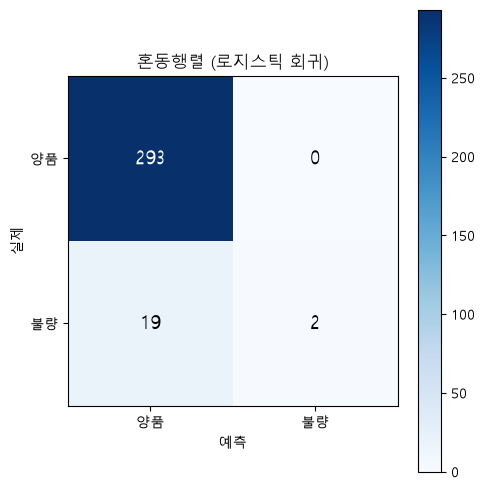

저장 완료: results/confusion_matrix.png
저장 완료: results/report.md

대조 결과: report.md 안 핵심 숫자가 모두 노트북 실행값과 일치함


In [7]:
import os
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

os.makedirs("results", exist_ok=True)

# ---------- (1) 혼동행렬 그림 (앞에서 이미 계산된 '행렬' 변수를 그대로 사용) ----------
라벨 = ["양품", "불량"]

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(행렬, cmap="Blues")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(라벨)
ax.set_yticklabels(라벨)
ax.set_xlabel("예측")
ax.set_ylabel("실제")
ax.set_title("혼동행렬 (로지스틱 회귀)")

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(행렬[i, j]), ha="center", va="center",
                color="white" if 행렬[i, j] > 행렬.max() / 2 else "black",
                fontsize=14)

plt.colorbar(im)
plt.tight_layout()
plt.savefig("results/confusion_matrix.png", dpi=150)
plt.show()

print("저장 완료: results/confusion_matrix.png")

# ---------- (2) report.md ----------
전체_행수 = df.shape[0]
# secom_clean.csv 원본 열 수 (센서 50 + result). df에 나중에 붙인 '불량여부'는 제외한 값
정제본_열수 = len(sensor_cols) + 1
불량비율_report = df["불량여부"].mean() * 100
학습건수 = len(X_train)
시험건수 = len(X_test)

모델이름 = type(model).__name__
전처리설명 = "StandardScaler로 표준화 (학습용 기준으로 fit, 학습용·시험용 모두 transform)"

def df_to_md(dframe):
    # iterrows()를 쓰면 한 행 안에서 정수·실수 열이 섞일 때 전부 실수로 바뀌므로,
    # 열 단위로 값을 꺼내 각 열의 원래 타입(정수/실수)을 그대로 유지한다
    cols = list(dframe.columns)
    header = "| " + " | ".join(str(c) for c in cols) + " |"
    sep = "|" + "|".join(["---"] * len(cols)) + "|"
    rows = []
    for i in range(len(dframe)):
        cells = [str(dframe[c].iloc[i]) for c in cols]
        rows.append("| " + " | ".join(cells) + " |")
    return "\n".join([header, sep] + rows)

결과표_md = df_to_md(비교표_지표[["모델", "정확도(%)", "재현율(%)", "정밀도(%)", "F1(%)"]])
문턱표_md = df_to_md(문턱_비교표)

report = f"""# 분류 결과 리포트

## 1. 데이터
| 항목 | 값 |
|---|---|
| 정제본 행 수 | {전체_행수} |
| 정제본 열 수 | {정제본_열수} |
| 불량 비율(%) | {round(불량비율_report, 2)} |
| 학습용 건수 | {학습건수} |
| 시험용 건수 | {시험건수} |

## 2. 모델
| 항목 | 값 |
|---|---|
| 모델 이름 | {모델이름} |
| 함께 적용한 처리 | {전처리설명} |

## 3. 결과 표
{결과표_md}

## 4. 혼동행렬 (실제 \\ 예측)
| 구분 | 예측: 양품 | 예측: 불량 |
|---|---|---|
| 실제: 양품 | {맞힌양품} | {헛경보} |
| 실제: 불량 | {놓친불량} | {잡은불량} |

## 5. 문턱별 비교표
{문턱표_md}

## 6. 그림 파일
confusion_matrix.png
"""

with open("results/report.md", "w", encoding="utf-8") as f:
    f.write(report)

print("저장 완료: results/report.md")

# ---------- 자기 대조: report.md 안 숫자 vs 노트북 실행값 ----------
검증항목 = {
    "정제본 행 수": str(전체_행수),
    "정제본 열 수": str(정제본_열수),
    "불량 비율(%)": str(round(불량비율_report, 2)),
    "학습용 건수": str(학습건수),
    "시험용 건수": str(시험건수),
    "혼동행렬 맞힌양품": str(맞힌양품),
    "혼동행렬 헛경보": str(헛경보),
    "혼동행렬 놓친불량": str(놓친불량),
    "혼동행렬 잡은불량": str(잡은불량),
    "문턱 0.5 잡은 불량": str(int(문턱_비교표.loc[0, "잡은 불량 건수"])),
    "문턱 0.1 헛경보": str(int(문턱_비교표.loc[3, "헛경보 건수"])),
}

with open("results/report.md", encoding="utf-8") as f:
    저장된_내용 = f.read()

불일치 = [이름 for 이름, 값 in 검증항목.items() if 값 not in 저장된_내용]

if 불일치:
    print("\n대조 결과 - 파일에서 못 찾은(불일치 가능) 항목:", 불일치)
else:
    print("\n대조 결과: report.md 안 핵심 숫자가 모두 노트북 실행값과 일치함")


---
## 직접 해보기 (도전) - 다른 모델도 같은 문턱에서 같을까

- 상황: 한 모델로만 문턱을 옮겨봤다. 다른 모델도 같은 모양일지는 모른다
- 할 일: 앞 실습에서 추천받은 다른 모델로 같은 표를 만들어 나란히 놓는다
- 결과물: 두 모델 문턱 비교표 1개

In [8]:
from sklearn.tree import DecisionTreeClassifier

# 아직 안 써본 추천 모델: 의사결정나무. 단위를 맞출 필요가 없으므로 원본 X_train 그대로 사용
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

# 결정트리도 "불량일 가능성"(확률)을 꺼내서 문턱을 바꿔가며 본다
불량확률_트리 = tree_model.predict_proba(X_test)[:, 1]

def 문턱표_만들기(확률, 이름):
    결과 = []
    for 문턱 in [0.5, 0.3, 0.2, 0.1]:
        문턱예측 = (확률 >= 문턱).astype(int)
        잡은불량_t = int(((문턱예측 == 1) & (y_test == 1)).sum())
        놓친불량_t = int(((문턱예측 == 0) & (y_test == 1)).sum())
        헛경보_t = int(((문턱예측 == 1) & (y_test == 0)).sum())
        재현율_t = recall_score(y_test, 문턱예측, zero_division=0) * 100
        정밀도_t = precision_score(y_test, 문턱예측, zero_division=0) * 100
        결과.append({
            "모델": 이름,
            "문턱": 문턱,
            "잡은 불량 건수": 잡은불량_t,
            "놓친 불량 건수": 놓친불량_t,
            "헛경보 건수": 헛경보_t,
            "재현율(%)": round(재현율_t, 2),
            "정밀도(%)": round(정밀도_t, 2),
        })
    return pd.DataFrame(결과)

# 앞에서 만든 문턱_비교표(로지스틱 회귀)는 건드리지 않고, 결정트리용은 새 이름으로 만든다
문턱_비교표_트리 = 문턱표_만들기(불량확률_트리, "결정트리")

print("결정트리 문턱별 비교표")
display(문턱_비교표_트리)

# 두 모델 표를 나란히 놓기 위해, 로지스틱 회귀 표에도 '모델' 열을 붙여서 위아래로 이어붙인다
문턱_비교표_로지스틱_표시용 = 문턱_비교표.copy()
문턱_비교표_로지스틱_표시용.insert(0, "모델", "로지스틱 회귀")

문턱_비교표_두모델 = pd.concat(
    [문턱_비교표_로지스틱_표시용, 문턱_비교표_트리],
    ignore_index=True,
)

print("\n두 모델 문턱별 비교표 (나란히)")
문턱_비교표_두모델


결정트리 문턱별 비교표


,모델,문턱,잡은 불량 건수,놓친 불량 건수,헛경보 건수,재현율(%),정밀도(%)
0,결정트리,0.5,5,16,26,23.81,16.13
1,결정트리,0.3,5,16,26,23.81,16.13
2,결정트리,0.2,5,16,26,23.81,16.13
3,결정트리,0.1,5,16,26,23.81,16.13



두 모델 문턱별 비교표 (나란히)


,모델,문턱,잡은 불량 건수,놓친 불량 건수,헛경보 건수,재현율(%),정밀도(%)
0,로지스틱 회귀,0.5,2,19,0,9.52,100.00
1,로지스틱 회귀,0.3,3,18,6,14.29,33.33
2,로지스틱 회귀,0.2,5,16,13,23.81,27.78
3,로지스틱 회귀,0.1,9,12,42,42.86,17.65
4,결정트리,0.5,5,16,26,23.81,16.13
5,결정트리,0.3,5,16,26,23.81,16.13
6,결정트리,0.2,5,16,26,23.81,16.13
7,결정트리,0.1,5,16,26,23.81,16.13


### 두 모델의 문턱 비교 (재현율 / 정밀도)

| 문턱 | [로지스틱 회귀] | [의사결정나무] |
|---|---|---|
| 0.5 | [0.095 / 1.000] | [0.238 / 0.161] |
| 0.3 | [0.143 / 0.333] | [0.238 / 0.161] |
| 0.2 | [0.238 / 0.278] | [0.238 / 0.161] |
| 0.1 | [0.429 / 0.176] | [0.238 / 0.161] |